In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as si

In [ ]:
# Analytical Black-Scholes formula (to compare against NSPT results)
def black_scholes_analytical(S0, K, T, r, sigma):
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Call Price
    call_price = (S0 * si.norm.cdf(d1, 0.0, 1.0) - K * np.exp(-r * T) * si.norm.cdf(d2, 0.0, 1.0))
    
    # Vega (sensitivity to sigma)
    vega = S0 * np.sqrt(T) * si.norm.pdf(d1, 0.0, 1.0)
    
    return call_price, vega

# NSPT simulation

def run_nspt_gbm(S0_val, K, T, r, sigma, N_paths=50000, N_steps=100):
    dt = T / N_steps
    sqrt_dt = np.sqrt(dt)
    
    # initializing arrays for all paths at once
    # S0_arr = The asset price paths
    # S1_arr = The sensitivity paths (starts at 0 because perturbation is 0 at t=0)
    S0_arr = np.full(N_paths, S0_val)
    S1_arr = np.zeros(N_paths)
    

    for _ in range(N_steps):
        # Generating random noise for all paths
        dW = np.random.randn(N_paths) * sqrt_dt
        
        S0_prev = S0_arr
        S1_prev = S1_arr
        
        # Updating zeroth order
        dS0 = r * S0_prev * dt + sigma * S0_prev * dW
        S0_arr = S0_prev + dS0
        
        # Updating first order
        dS1 = r * S1_prev * dt + (sigma * S1_prev + S0_prev) * dW
        S1_arr = S1_prev + dS1

    # Discount factor
    discount = np.exp(-r * T)
    
    # Zeroth order payoff
    # V = max(S - K, 0)
    payoffs_0 = np.maximum(S0_arr - K, 0)
    price_est = discount * np.mean(payoffs_0)
    
    # First order payoff
    payoffs_1 = np.where(S0_arr > K, S1_arr, 0.0)
    vega_est = discount * np.mean(payoffs_1)
    
    return price_est, vega_est, S0_arr, S1_arr

In [ ]:
# Parameters
S0 = 100.0   # Initial Asset Price
K = 100.0    # Strike Price
T = 1.0      # One year timline
r = 0.05     # Risk free rate (5%)
sigma = 0.2  # Volatility (20%)

np.random.seed(42)

print(f"--- Simulation Setup ---")
print(f"Asset: {S0}, Strike: {K}, Vol: {sigma}, Time: {T}")
print(f"Simulating {50000} paths...")

nspt_price, nspt_vega, final_S0, final_S1 = run_nspt_gbm(S0, K, T, r, sigma, N_paths=100000, N_steps=200)

ana_price, ana_vega = black_scholes_analytical(S0, K, T, r, sigma)

--- Simulation Setup ---
Asset: 100.0, Strike: 100.0, Vol: 0.2, Time: 1.0
Simulating 50000 paths...


In [ ]:
print("\n--- RESULTS ---")
print(f"{'Quantity':<15} | {'NSPT Estimate':<15} | {'Analytical':<15} | {'Error %':<10}")
print("-" * 65)
print(f"{'Call Price':<15} | {nspt_price:<15.4f} | {ana_price:<15.4f} | {abs(nspt_price-ana_price)/ana_price*100:.3f}%")
print(f"{'Vega (dC/dSig)':<15} | {nspt_vega:<15.4f} | {ana_vega:<15.4f} | {abs(nspt_vega-ana_vega)/ana_vega*100:.3f}%")


--- RESULTS ---
Quantity        | NSPT Estimate   | Analytical      | Error %   
-----------------------------------------------------------------
Call Price      | 10.4641         | 10.4506         | 0.129%
Vega (dC/dSig)  | 37.5559         | 37.5240         | 0.085%


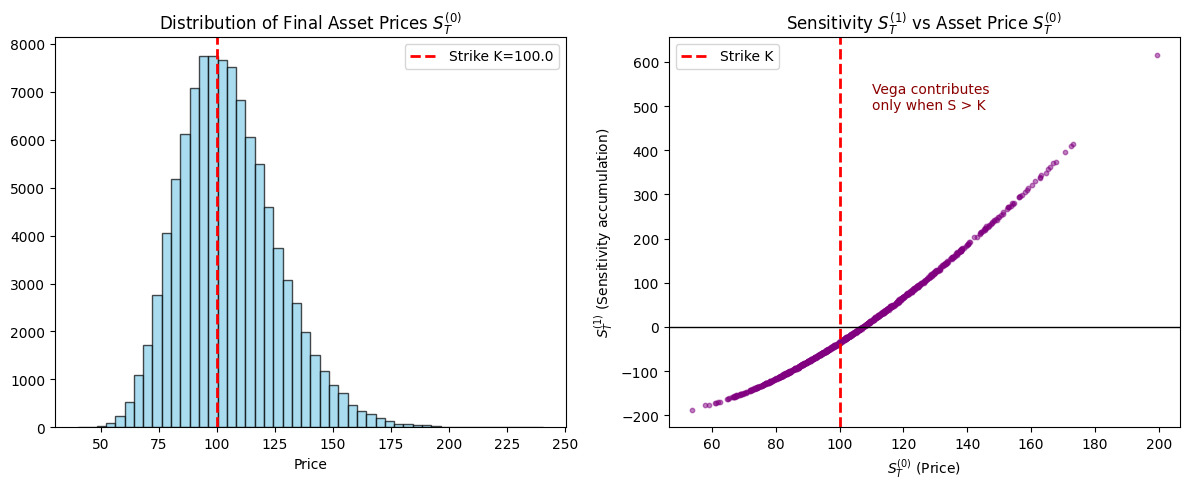

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histogram
ax[0].hist(final_S0, bins=50, color='skyblue', edgecolor='black', alpha=0.7)
ax[0].axvline(K, color='red', linestyle='--', linewidth=2, label=f'Strike K={K}')
ax[0].set_title("Distribution of Final Asset Prices $S^{(0)}_T$")
ax[0].set_xlabel("Price")
ax[0].legend()

# Scatter Plot
ax[1].scatter(final_S0[:1000], final_S1[:1000], alpha=0.5, s=10, c='purple')
ax[1].axvline(K, color='red', linestyle='--', linewidth=2, label='Strike K')
ax[1].axhline(0, color='black', lw=1)
ax[1].set_title("Sensitivity $S^{(1)}_T$ vs Asset Price $S^{(0)}_T$")
ax[1].set_xlabel("$S^{(0)}_T$ (Price)")
ax[1].set_ylabel("$S^{(1)}_T$ (Sensitivity accumulation)")
ax[1].text(K*1.1, np.max(final_S1[:1000])*0.8, "Vega contributes\nonly when S > K", fontsize=10, color='darkred')
ax[1].legend()

plt.tight_layout()
plt.show()